In [ ]:
# ============================================================
# AUTO-discover ALL (B, n_i, phi) combos under ../data/results/{EXP_FOLDER}/
# and save extracted estimates into ONE long-form CSV.
#
# Extracts per seed:
#   - GPmodel
#   - GPArealModel
#   - VI_best_tau_by_ELBO (best tau per seed using mean(last TAIL_K) of ELBO trace)
#
# Saved columns:
#   EXP_FOLDER, B, n_i, phi_true, seed, method,
#   Beta, Beta_vec, Phi, Sigmasq, Tausq, ELBO, tau_selected, Sigmasq_phi
#
# Sigmasq_phi definition (your request):
#   - VI_best_tau_by_ELBO: Sigmasq * Phi
#   - GPmodel/GPArealModel: Sigmasq * (1/Phi)
# ============================================================

import os, glob, re
import numpy as np
import pandas as pd
import torch
# utils.py is in the src folder one level up, so we need to adjust the import path accordingly
import sys
sys.path.append('../src')
from utils import round_to_perm
# -----------------------
# USER CHOICES
# -----------------------
EXP_FOLDER = "vary_B2"   # "vary_B2" or "vary_B2_annealed" etc.
RESULTS_ROOT = os.path.join("..", "data", "results", EXP_FOLDER)

TAIL_K = 5
TRIM_TRAILING_ZEROS = True
ZERO_ATOL = 0.0          # set 1e-12 if needed

OUT_DIR = os.path.join("..", "data", "summaries", EXP_FOLDER)
os.makedirs(OUT_DIR, exist_ok=True)
CSV_OUT = os.path.join(OUT_DIR, f"estimates_long_{EXP_FOLDER}.csv")

# -----------------------
# HELPERS
# -----------------------
def load_pt(path):
    return torch.load(path, map_location="cpu", weights_only=False)

def to_float(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        return float(x.reshape(-1)[0].item()) if x.numel() else np.nan
    try:
        return float(np.asarray(x).reshape(-1)[0])
    except Exception:
        return np.nan

def beta_to_scalar(beta):
    beta_vec_str = None
    if isinstance(beta, torch.Tensor):
        beta = beta.detach().cpu().numpy()
    if beta is None:
        return np.nan, None
    arr = np.asarray(beta).reshape(-1)
    if arr.size == 0:
        return np.nan, None
    if arr.size > 1:
        beta_vec_str = np.array2string(arr, precision=6, separator=",")
    return float(arr[0]), beta_vec_str

def trim_trailing_zeros(x, atol=0.0):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.size == 0:
        return x
    i = x.size - 1
    while i > 0 and np.isfinite(x[i]) and np.isclose(x[i], 0.0, atol=atol):
        i -= 1
    return x[:i+1]

def elbo_score_from_trace(trace, tail_k=5):
    if trace is None:
        return None, None
    if isinstance(trace, torch.Tensor):
        trace = trace.detach().cpu().numpy()
    x = np.asarray(trace, dtype=float).reshape(-1)
    if x.size == 0:
        return None, None
    if TRIM_TRAILING_ZEROS:
        x = trim_trailing_zeros(x, atol=ZERO_ATOL)
    if x.size == 0 or np.max(np.abs(x)) == 0.0:
        return None, x
    k = min(int(tail_k), x.size)
    return float(np.nanmean(x[-k:])), x

def get_vi_tau_keys(result_dict):
    out = []
    for k in result_dict.keys():
        if isinstance(k, str) and k.startswith("VIGP_unlinked_tau_"):
            try:
                tau = float(k.split("VIGP_unlinked_tau_")[1])
                out.append((tau, k))
            except Exception:
                pass
    return sorted(out, key=lambda z: z[0])

def compute_sigmasq_phi(method, sigmasq, phi):
    if not np.isfinite(sigmasq) or not np.isfinite(phi) or phi == 0:
        return np.nan
    if method in ["GPmodel", "GPArealModel"]:
        return sigmasq * (1.0 / phi)
    else:
        return sigmasq * phi

# -----------------------
# DISCOVER combos by scanning folders
# Expected pattern:
#   RESULTS_ROOT/B_{B}_n_{n_i}/phi_{phi}/results_seed_{seed}.pt
# -----------------------
combo_re = re.compile(r"B_(\d+)_n_(\d+)")
phi_re   = re.compile(r"phi_([^/\\]+)$")
seed_re  = re.compile(r"results_seed_(\d+)\.pt$")

rows = []
missing_valid_vi = 0
missing_any_vi = 0

# find all results_seed_*.pt anywhere under RESULTS_ROOT
all_result_files = glob.glob(os.path.join(RESULTS_ROOT, "B_*_n_*", "phi_*", "results_seed_*.pt"))
all_result_files = sorted(all_result_files)

if len(all_result_files) == 0:
    raise FileNotFoundError(f"No results found under: {RESULTS_ROOT}/B_*_n_*/phi_*/results_seed_*.pt")

for path in all_result_files:
    # parse B, n_i, phi_true from folder structure
    phi_dir = os.path.dirname(path)                # .../phi_{phi}
    bn_dir  = os.path.dirname(phi_dir)             # .../B_{B}_n_{n_i}

    m_bn = combo_re.search(os.path.basename(bn_dir))
    m_phi = phi_re.search(phi_dir.replace("\\", "/"))
    m_seed = seed_re.search(os.path.basename(path))

    if (m_bn is None) or (m_phi is None) or (m_seed is None):
        continue

    B = int(m_bn.group(1))
    n_i = int(m_bn.group(2))
    # keep phi_true numeric if possible
    try:
        phi_true = float(m_phi.group(1))
    except Exception:
        phi_true = m_phi.group(1)

    seed = int(m_seed.group(1))

    result = load_pt(path)

    # ---- GPmodel + GPArealModel ----
    for model in ["GPmodel", "GPArealModel"]:
        if model not in result or not isinstance(result[model], dict):
            continue
        mm = result[model]

        beta_scalar, beta_vec_str = beta_to_scalar(mm.get("beta", np.nan))
        phi_hat   = 1/to_float(mm.get("phi", np.nan))
        sigmasq   = to_float(mm.get("sigmasq", np.nan))
        tausq     = to_float(mm.get("tausq", np.nan))

        rows.append({
            "EXP_FOLDER": EXP_FOLDER,
            "B": B,
            "n_i": n_i,
            "phi_true": phi_true,
            "seed": seed,
            "method": model,
            "Beta": beta_scalar,
            "Beta_vec": beta_vec_str,
            "Phi": phi_hat,
            "Sigmasq": sigmasq,
            "Tausq": tausq,
            "ELBO": np.nan,
            "tau_selected": np.nan,
            "Sigmasq_phi": compute_sigmasq_phi(model, sigmasq, phi_hat),
            "results_path": path,  # helpful for debugging; drop later if you want
        })

    # ---- VI: choose best tau per seed by ELBO ----
    vi_keys = get_vi_tau_keys(result)
    if len(vi_keys) == 0:
        missing_any_vi += 1
        continue

    best_score = -np.inf
    best_tau = np.nan
    best_key = None

    for tau, key in vi_keys:
        vi = result.get(key, None)
        if not isinstance(vi, dict):
            continue
        score, _ = elbo_score_from_trace(vi.get("loss_vector", None), tail_k=TAIL_K)
        if score is None or not np.isfinite(score):
            continue
        if score > best_score:
            best_score = score
            best_tau = tau
            best_key = key

    if best_key is None:
        missing_valid_vi += 1
        continue

    vi = result[best_key]

    beta_hat = to_float(vi.get("mu_lambda_beta", np.nan))
    phi_hat  = to_float(vi.get("mean_phi", np.nan))

    a1 = to_float(vi.get("lambda_a1", np.nan)); b1 = to_float(vi.get("lambda_b1", np.nan))
    a2 = to_float(vi.get("lambda_a2", np.nan)); b2 = to_float(vi.get("lambda_b2", np.nan))

    sigmasq_hat = (b1 / (a1 - 1.0)) if np.isfinite(a1) and a1 > 1 else np.nan
    tausq_hat   = (b2 / (a2 - 1.0)) if np.isfinite(a2) and a2 > 1 else np.nan

    perm_matrix_s = result['true_perms'].get("perm_s_true")
    perm_matrix_x = result['true_perms'].get("perm_x_true") 
    n_correct_perm_x = 0
    n_correct_perm_s = 0

    M_X_star = vi.get("M_X_star", None)
    M_S_star = vi.get("M_S_star", None)

    if M_X_star is not None and perm_matrix_x is not None:
        M_X_rounded = round_to_perm(M_X_star)
        perm_x_torch = torch.tensor(perm_matrix_x.T, dtype=torch.float32)
        n_correct_perm_x = int(torch.sum(perm_x_torch * M_X_rounded).item())

    if M_S_star is not None and perm_matrix_s is not None:
        M_S_rounded = round_to_perm(M_S_star)
        perm_s_torch = torch.tensor(perm_matrix_s.T, dtype=torch.float32)
        n_correct_perm_s = int(torch.sum(perm_s_torch * M_S_rounded).item())

    rows.append({
        "EXP_FOLDER": EXP_FOLDER,
        "B": B,
        "n_i": n_i,
        "phi_true": phi_true,
        "seed": seed,
        "method": "VI_best_tau_by_ELBO",
        "Beta": beta_hat,
        "Beta_vec": None,
        "Phi": phi_hat,
        "Sigmasq": sigmasq_hat,
        "Tausq": tausq_hat,
        "ELBO": float(best_score),
        "tau_selected": float(best_tau),
        "n_correct_perm_s": n_correct_perm_s,
        "n_correct_perm_x": n_correct_perm_x,
        "results_path": path,
    })

df = pd.DataFrame(rows)

# Optional: sort nicely
sort_cols = ["n_i", "B", "phi_true", "seed", "method"]
for c in sort_cols:
    if c not in df.columns:
        sort_cols.remove(c)
df = df.sort_values(sort_cols).reset_index(drop=True)

df.to_csv(CSV_OUT, index=False)

print(f"Saved CSV: {CSV_OUT}")
print(f"Total rows: {len(df)}")
print(f"Seeds with no VI keys: {missing_any_vi} | seeds with no valid VI ELBO: {missing_valid_vi}")
print(df.head())

/var/folders/kj/tn21r9y15yz4_21vggchc7sc0000gp/T/ipykernel_33537/947240977.py:230: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  perm_x_torch = torch.tensor(perm_matrix_x.T, dtype=torch.float32)
/var/folders/kj/tn21r9y15yz4_21vggchc7sc0000gp/T/ipykernel_33537/947240977.py:231: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  n_correct_perm_x = int(torch.sum(perm_x_torch * M_X_rounded).item())
/var/folders/kj/tn21r9y15yz4_21vggchc7sc0000gp/T/ipykernel_33537/947240977.py:235: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  perm_s_torch = torch.tensor(perm_matrix_s.T, dtype=torch.float32)
/var/folders/kj/

Loading: ../data/results/vary_B2/B_81_n_8/phi_2.0/results_seed_4.pt


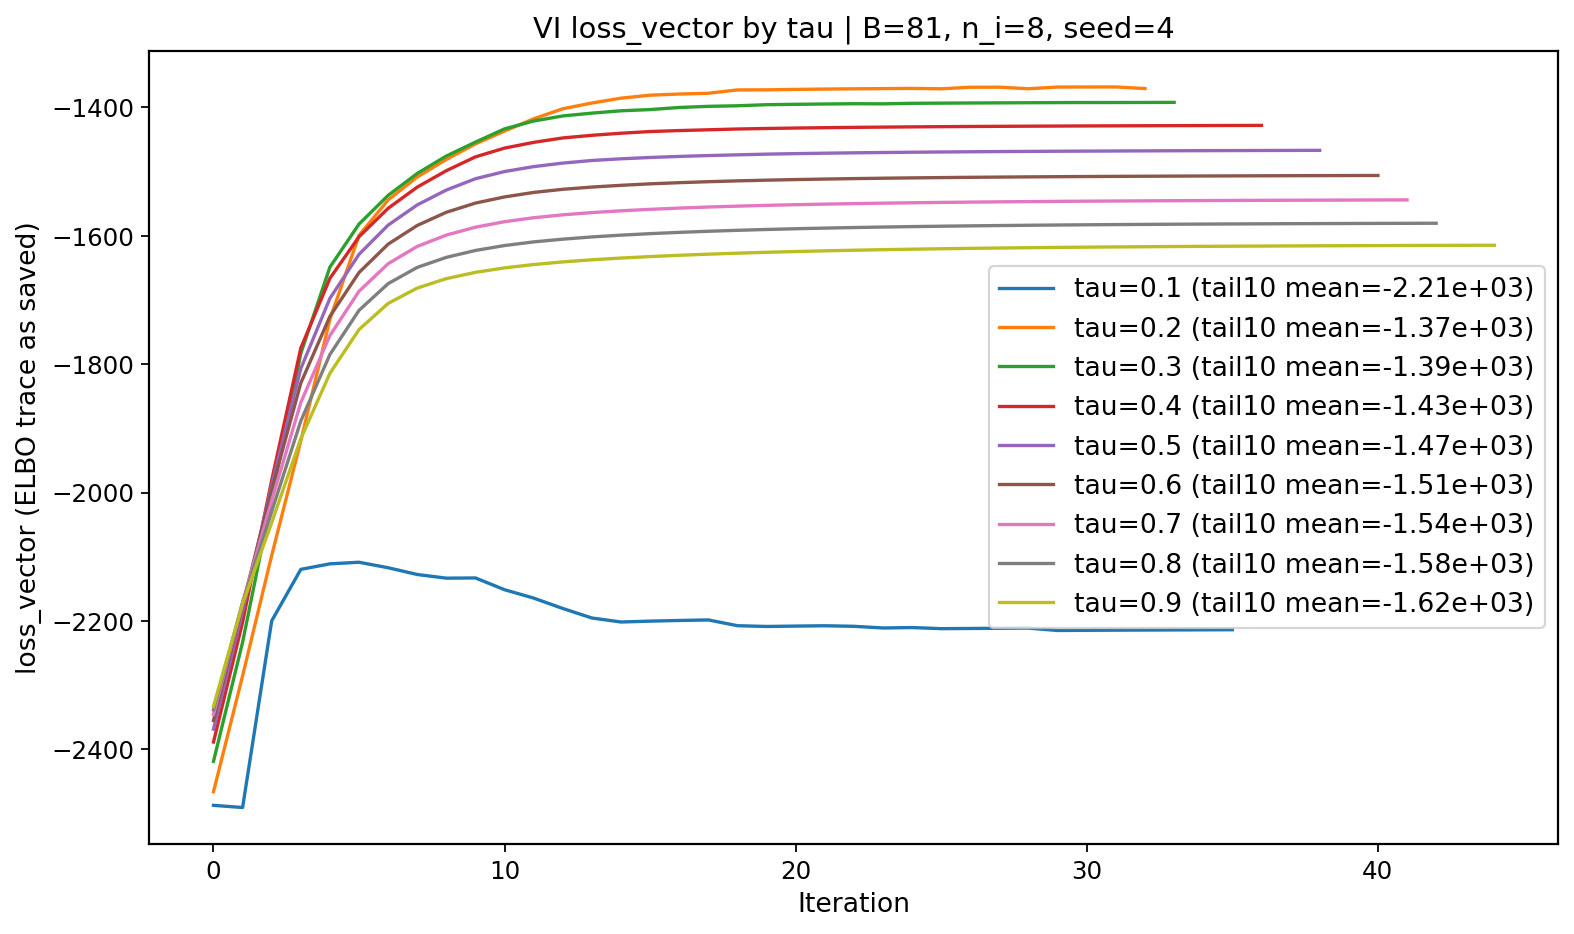

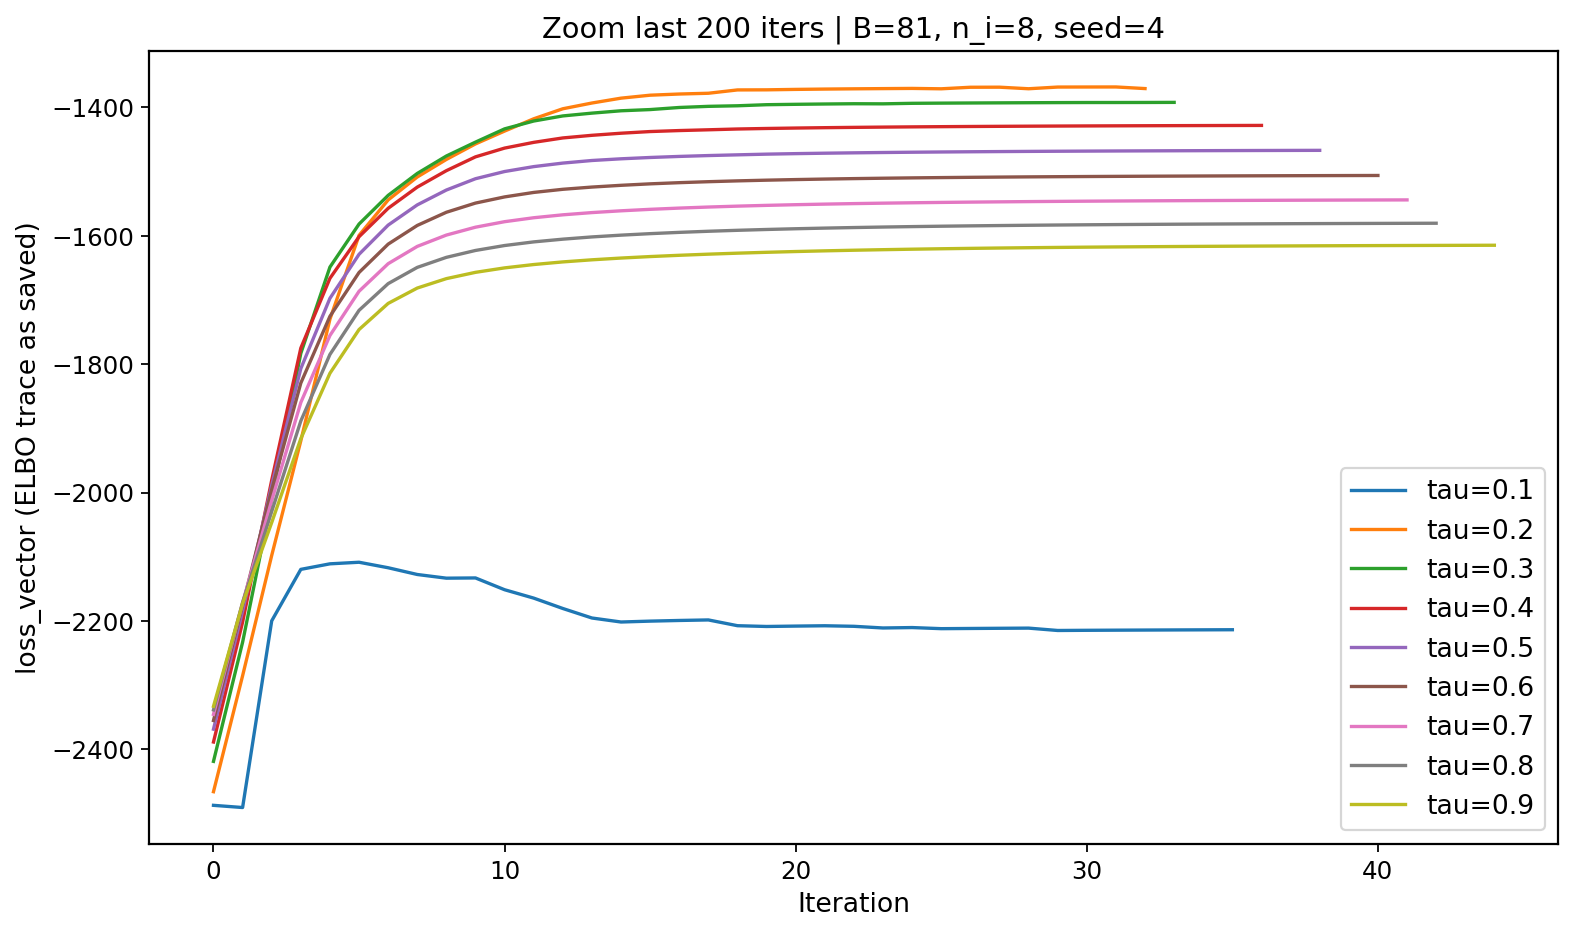


Convergence summary (higher tail-mean = better if loss_vector is ELBO):
  tau=0.1 | iters=  36 | tail_mean(last 10): -2213.41 | last: -2213.71
  tau=0.2 | iters=  33 | tail_mean(last 10): -1369.72 | last: -1370.83
  tau=0.3 | iters=  34 | tail_mean(last 10): -1392.91 | last: -1392.34
  tau=0.4 | iters=  37 | tail_mean(last 10): -1428.84 | last: -1428.21
  tau=0.5 | iters=  39 | tail_mean(last 10): -1467.66 | last: -1467.04
  tau=0.6 | iters=  41 | tail_mean(last 10): -1506.8 | last: -1506.19
  tau=0.7 | iters=  42 | tail_mean(last 10): -1544.88 | last: -1544.23
  tau=0.8 | iters=  43 | tail_mean(last 10): -1581.26 | last: -1580.57
  tau=0.9 | iters=  45 | tail_mean(last 10): -1615.52 | last: -1614.86


In [19]:
import os, glob
import numpy as np
import torch
import matplotlib.pyplot as plt

# -----------------------
# USER CHOICES (edit these)
# -----------------------
EXP_FOLDER = "vary_B2"   # e.g., "vary_B2", "vary_B2_annealed"
B    = 81
n_i  = 8
seed = 4

PHI_TRUE = None          # set to float like 2.0 to pin it; None => auto-pick if unique
TAU_WHITELIST = None     # e.g., [0.01, 0.05, 0.1] ; None => plot all taus found

TRIM_TRAILING_ZEROS = True
ZERO_ATOL = 0.0
TAIL_K = 10              # for printing tail-mean convergence summary
ZOOM_LAST = 200           # second plot zooms into last iterations; set None to skip

RESULTS_ROOT = os.path.join("..", "data", "results", EXP_FOLDER)

# -----------------------
# HELPERS (same logic as your script)
# -----------------------
def load_pt(path):
    return torch.load(path, map_location="cpu", weights_only=False)

def trim_trailing_zeros(x, atol=0.0):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.size == 0:
        return x
    i = x.size - 1
    while i > 0 and np.isfinite(x[i]) and np.isclose(x[i], 0.0, atol=atol):
        i -= 1
    return x[:i+1]

def get_vi_tau_keys(result_dict):
    out = []
    for k in result_dict.keys():
        if isinstance(k, str) and k.startswith("VIGP_unlinked_tau_"):
            try:
                tau = float(k.split("VIGP_unlinked_tau_")[1])
                out.append((tau, k))
            except Exception:
                pass
    return sorted(out, key=lambda z: z[0])

def as_1d_np(x):
    if x is None:
        return np.array([])
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu().numpy()
    x = np.asarray(x, dtype=float).reshape(-1)
    if TRIM_TRAILING_ZEROS:
        x = trim_trailing_zeros(x, atol=ZERO_ATOL)
    return x

# -----------------------
# Locate the one results file for (B, n_i, phi, seed)
# -----------------------
bn_dir = os.path.join(RESULTS_ROOT, f"B_{B}_n_{n_i}")
cands = sorted(glob.glob(os.path.join(bn_dir, "phi_*", f"results_seed_{seed}.pt")))
if len(cands) == 0:
    raise FileNotFoundError(f"No file found under: {bn_dir}/phi_*/results_seed_{seed}.pt")

if PHI_TRUE is None:
    # if multiple phi folders exist, try to pick unique; otherwise use first and warn
    if len(cands) > 1:
        print("WARNING: multiple phi_* folders found. Using the FIRST one.\n"
              "Set PHI_TRUE (e.g., 2.0) to pin a specific phi folder.\n")
    results_path = cands[0]
else:
    # match phi_{PHI_TRUE} folder by string contains (robust-ish)
    phi_str = str(PHI_TRUE)
    matches = [p for p in cands if (f"phi_{phi_str}" in p.replace("\\", "/"))]
    if len(matches) == 0:
        raise FileNotFoundError(f"No match for PHI_TRUE={PHI_TRUE}. Candidates:\n" + "\n".join(cands))
    results_path = matches[0]

print("Loading:", results_path)
result = load_pt(results_path)

# -----------------------
# Extract & plot loss_vector traces for all taus
# -----------------------
tau_keys = get_vi_tau_keys(result)
if len(tau_keys) == 0:
    raise KeyError("No VI keys found (expected keys like 'VIGP_unlinked_tau_{tau}').")

if TAU_WHITELIST is not None:
    tau_set = set([float(t) for t in TAU_WHITELIST])
    tau_keys = [(t, k) for (t, k) in tau_keys if float(t) in tau_set]

if len(tau_keys) == 0:
    raise ValueError("After filtering, no taus remain to plot.")

# Collect traces + summaries
series = []
for tau, key in tau_keys:
    vi = result.get(key, None)
    if not isinstance(vi, dict):
        continue
    trace = as_1d_np(vi.get("loss_vector", None))
    if trace.size == 0:
        continue
    k = min(int(TAIL_K), trace.size)
    tail_mean = float(np.nanmean(trace[-k:]))
    series.append((tau, trace, tail_mean))

if len(series) == 0:
    raise ValueError("No non-empty loss_vector traces found for the selected taus.")

# Sort by tau
series.sort(key=lambda z: z[0])

# ---- Plot full traces ----
plt.figure()
for tau, trace, tail_mean in series:
    plt.plot(trace, label=f"tau={tau:g} (tail{min(TAIL_K, trace.size)} mean={tail_mean:.3g})")
plt.xlabel("Iteration")
plt.ylabel("loss_vector (ELBO trace as saved)")
plt.title(f"VI loss_vector by tau | B={B}, n_i={n_i}, seed={seed}")
plt.legend()
plt.tight_layout()
plt.show()

# ---- Optional zoom into last iterations ----
if ZOOM_LAST is not None:
    plt.figure()
    for tau, trace, tail_mean in series:
        start = max(0, trace.size - int(ZOOM_LAST))
        plt.plot(np.arange(start, trace.size), trace[start:], label=f"tau={tau:g}")
    plt.xlabel("Iteration")
    plt.ylabel("loss_vector (ELBO trace as saved)")
    plt.title(f"Zoom last {ZOOM_LAST} iters | B={B}, n_i={n_i}, seed={seed}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- Print a quick convergence summary ----
print("\nConvergence summary (higher tail-mean = better if loss_vector is ELBO):")
for tau, trace, tail_mean in series:
    print(f"  tau={tau:g} | iters={trace.size:4d} | tail_mean(last {min(TAIL_K, trace.size)}): {tail_mean:.6g} | last: {trace[-1]:.6g}")

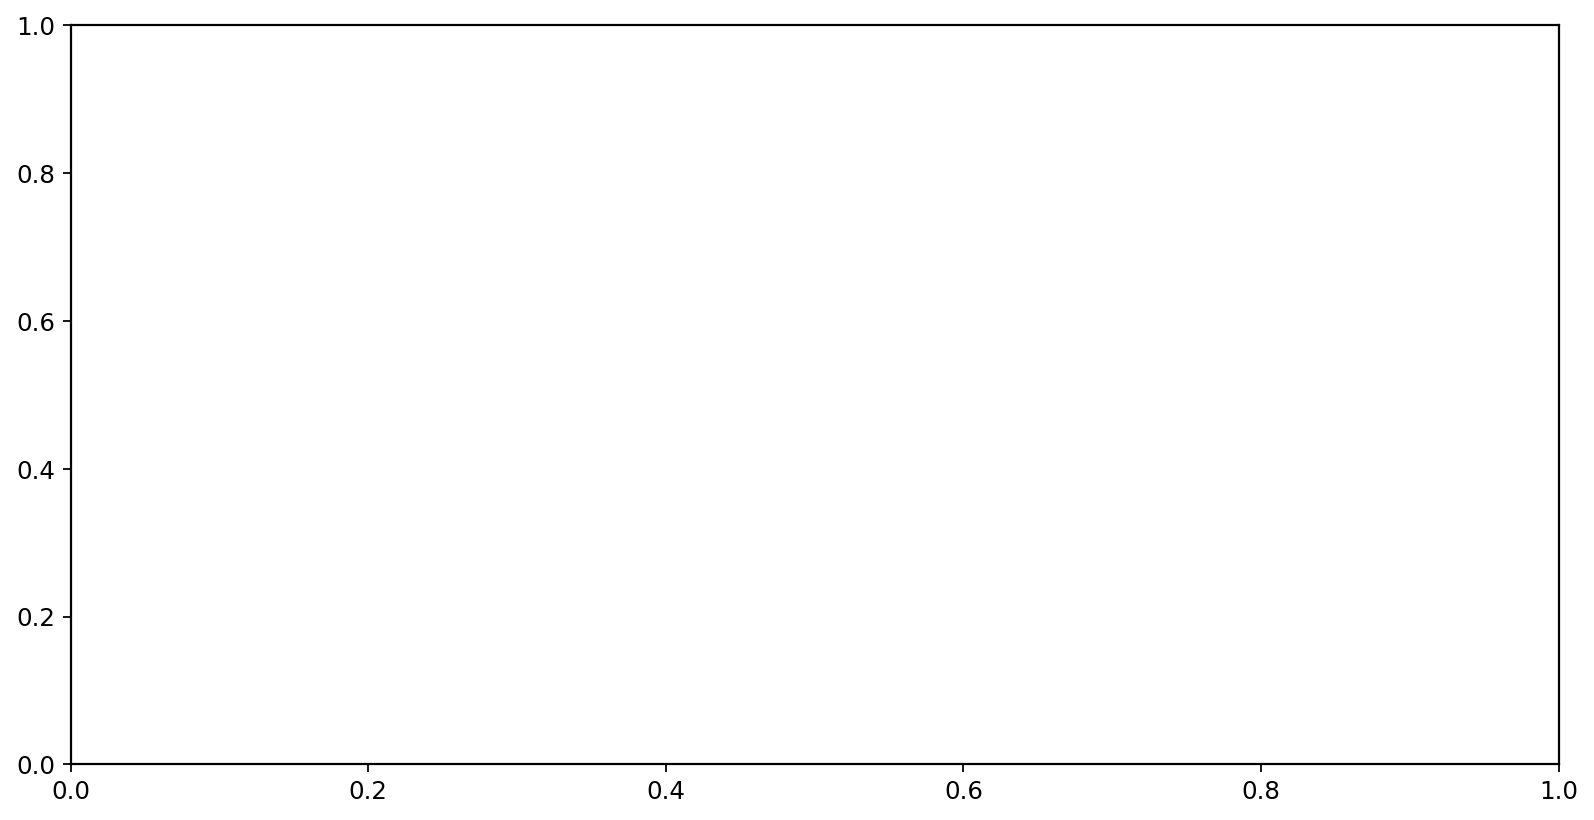

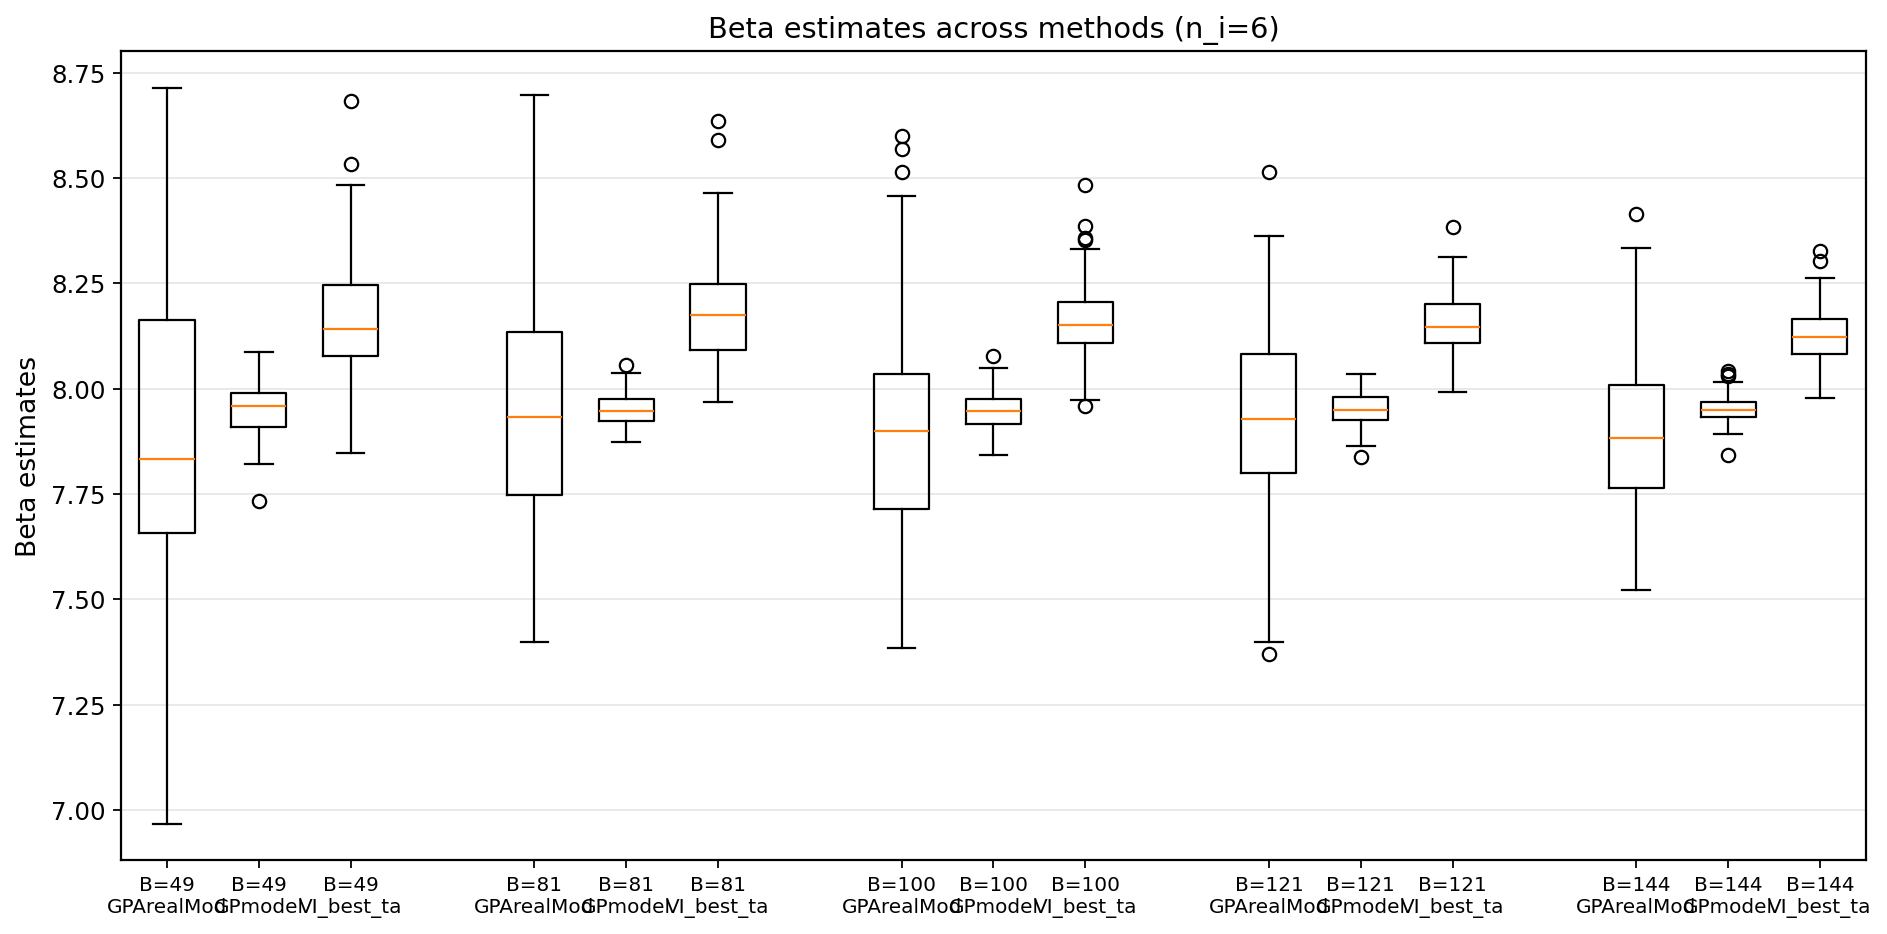

<Figure size 1600x960 with 0 Axes>

In [13]:
#generate some summary stats
summary = df.groupby("method").agg({
    "Beta": ["mean", "std"],
    "Phi": ["mean", "std"],
    "Sigmasq": ["mean", "std"],
    "Tausq": ["mean", "std"],
    "ELBO": ["mean", "std"],
    "tau_selected": ["mean", "std"],
    "Sigmasq_phi": ["mean", "std"],
})

# Boxplot: fix n_i, vary B, compare Beta estimates across methods
n_i_fixed = 6  # or choose another value from df['n_i'].unique()
df_filtered = df[df['n_i'] == n_i_fixed]

fig, ax = plt.subplots(figsize=(12, 6))

import matplotlib.pyplot as plt          # add this once so `plt` is defined

#generate some summary stats
summary = df.groupby("method").agg({
    "Beta": ["mean", "std"],
    "Phi": ["mean", "std"],
    "Sigmasq": ["mean", "std"],
    "Tausq": ["mean", "std"],
    "ELBO": ["mean", "std"],
    "tau_selected": ["mean", "std"],
    "Sigmasq_phi": ["mean", "std"],
})

# Boxplot: fix n_i, vary B, compare Beta estimates across methods
n_i_fixed = 6  # or choose another value from df['n_i'].unique()
df_filtered = df[df['n_i'] == n_i_fixed]

fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for boxplot
B_values = sorted(df_filtered['B'].unique())
methods = sorted(df_filtered['method'].unique())

positions = []
labels = []
data_to_plot = []
pos = 1

for B in B_values:
    for method in methods:
        subset = df_filtered[(df_filtered['B'] == B) & (df_filtered['method'] == method)]['Beta']
        if len(subset) > 0:
            data_to_plot.append(subset.values)
            positions.append(pos)
            labels.append(f"B={B}\n{method[:10]}")
            pos += 1
    pos += 1  # gap between B groups

ax.boxplot(data_to_plot, positions=positions, widths=0.6)
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Beta estimates")
ax.set_title(f"Beta estimates across methods (n_i={n_i_fixed})")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# recolor the boxes by method – easiest is to redraw with `patch_artist=True`
ax.clear()

color_map = {
    "GPmodel": "skyblue",
    "GPArealModel": "lightgreen",
    "VI_best_tau_by_ELBO": "salmon",
}

bp = ax.boxplot(data_to_plot,
                positions=positions,
                widths=0.6,
                patch_artist=True)

# assign a fill colour to each box according to its method
for patch, lbl in zip(bp['boxes'], labels):
    method = lbl.split("\n")[1]
    patch.set_facecolor(color_map.get(method, "white"))
    patch.set_edgecolor("black")

# optionally tidy up the median/whisker/cap colours
for line in bp['medians']:
    line.set(color="black", linewidth=1)
for line in bp['whiskers'] + bp['caps']:
    line.set(color="black", linewidth=1)

# re‑apply the tick labels and other formatting
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Beta estimates")
ax.set_title(f"Beta estimates across methods (n_i={n_i_fixed})")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# AUTO-discover ALL (B, n_i, phi) combos under ../data/results/{EXP_FOLDER}/
# and save extracted estimates into ONE long-form CSV.
#
# Extracts per seed:
#   - GPmodel
#   - GPArealModel
#   - VI_best_tau_by_ELBO (best tau per seed using mean(last TAIL_K) of ELBO trace)
#
# Saved columns:
#   EXP_FOLDER, B, n_i, phi_true, seed, method,
#   Beta, Beta_vec, Phi, Sigmasq, Tausq, ELBO, tau_selected, Sigmasq_phi
#
# Sigmasq_phi definition (your request):
#   - VI_best_tau_by_ELBO: Sigmasq * Phi
#   - GPmodel/GPArealModel: Sigmasq * (1/Phi)
# ============================================================

from math import perm
import os, glob, re
import numpy as np
import pandas as pd
import torch
import sys
sys.path.append('../src')
from utils import round_to_perm

# -----------------------
# USER CHOICES
# -----------------------
EXP_FOLDER = "vary_B2_annealed"   # "vary_B2" or "vary_B2_annealed" etc.
RESULTS_ROOT = os.path.join("..", "data", "results", EXP_FOLDER)

TAIL_K = 5
TRIM_TRAILING_ZEROS = True
ZERO_ATOL = 0.0          # set 1e-12 if needed

OUT_DIR = os.path.join("..", "data", "summaries", EXP_FOLDER)
os.makedirs(OUT_DIR, exist_ok=True)
CSV_OUT = os.path.join(OUT_DIR, f"estimates_long_{EXP_FOLDER}_annealed.csv")

# -----------------------
# HELPERS
# -----------------------
def load_pt(path):
    return torch.load(path, map_location="cpu", weights_only=False)

def to_float(x):
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()
        return float(x.reshape(-1)[0].item()) if x.numel() else np.nan
    try:
        return float(np.asarray(x).reshape(-1)[0])
    except Exception:
        return np.nan

def beta_to_scalar(beta):
    beta_vec_str = None
    if isinstance(beta, torch.Tensor):
        beta = beta.detach().cpu().numpy()
    if beta is None:
        return np.nan, None
    arr = np.asarray(beta).reshape(-1)
    if arr.size == 0:
        return np.nan, None
    if arr.size > 1:
        beta_vec_str = np.array2string(arr, precision=6, separator=",")
    return float(arr[0]), beta_vec_str

def trim_trailing_zeros(x, atol=0.0):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.size == 0:
        return x
    i = x.size - 1
    while i > 0 and np.isfinite(x[i]) and np.isclose(x[i], 0.0, atol=atol):
        i -= 1
    return x[:i+1]

def elbo_score_from_trace(trace, tail_k=5):
    if trace is None:
        return None, None
    if isinstance(trace, torch.Tensor):
        trace = trace.detach().cpu().numpy()
    x = np.asarray(trace, dtype=float).reshape(-1)
    if x.size == 0:
        return None, None
    if TRIM_TRAILING_ZEROS:
        x = trim_trailing_zeros(x, atol=ZERO_ATOL)
    if x.size == 0 or np.max(np.abs(x)) == 0.0:
        return None, x
    k = min(int(tail_k), x.size)
    return float(np.nanmean(x[-k:])), x

def get_vi_tau_keys(result_dict):
    out = []
    for k in result_dict.keys():
        if isinstance(k, str) and k.startswith("VIGP_unlinked_tau_"):
            try:
                tau = float(k.split("VIGP_unlinked_tau_")[1])
                out.append((tau, k))
            except Exception:
                pass
    return sorted(out, key=lambda z: z[0])

def compute_sigmasq_phi(method, sigmasq, phi):
    if not np.isfinite(sigmasq) or not np.isfinite(phi) or phi == 0:
        return np.nan
    if method in ["GPmodel", "GPArealModel"]:
        return sigmasq * (1.0 / phi)
    else:
        return sigmasq * phi

# -----------------------
# DISCOVER combos by scanning folders
# Expected pattern:
#   RESULTS_ROOT/B_{B}_n_{n_i}/phi_{phi}/results_seed_{seed}.pt
# -----------------------
combo_re = re.compile(r"B_(\d+)_n_(\d+)")
phi_re   = re.compile(r"phi_([^/\\]+)$")
seed_re  = re.compile(r"results_seed_(\d+)\.pt$")

rows = []
missing_valid_vi = 0
missing_any_vi = 0

# find all results_seed_*.pt anywhere under RESULTS_ROOT
all_result_files = glob.glob(os.path.join(RESULTS_ROOT, "B_*_n_*", "phi_*", "results_seed_*.pt"))
all_result_files = sorted(all_result_files)

if len(all_result_files) == 0:
    raise FileNotFoundError(f"No results found under: {RESULTS_ROOT}/B_*_n_*/phi_*/results_seed_*.pt")

for path in all_result_files:
    # parse B, n_i, phi_true from folder structure
    phi_dir = os.path.dirname(path)                # .../phi_{phi}
    bn_dir  = os.path.dirname(phi_dir)             # .../B_{B}_n_{n_i}

    m_bn = combo_re.search(os.path.basename(bn_dir))
    m_phi = phi_re.search(phi_dir.replace("\\", "/"))
    m_seed = seed_re.search(os.path.basename(path))

    if (m_bn is None) or (m_phi is None) or (m_seed is None):
        continue

    B = int(m_bn.group(1))
    n_i = int(m_bn.group(2))
    # keep phi_true numeric if possible
    try:
        phi_true = float(m_phi.group(1))
    except Exception:
        phi_true = m_phi.group(1)

    seed = int(m_seed.group(1))

    result = load_pt(path)

    # ---- GPmodel + GPArealModel ----
    for model in ["GPmodel", "GPArealModel"]:
        if model not in result or not isinstance(result[model], dict):
            continue
        mm = result[model]

        beta_scalar, beta_vec_str = beta_to_scalar(mm.get("beta", np.nan))
        phi_hat   = 1/to_float(mm.get("phi", np.nan))
        sigmasq   = to_float(mm.get("sigmasq", np.nan))
        tausq     = to_float(mm.get("tausq", np.nan))

        rows.append({
            "EXP_FOLDER": EXP_FOLDER,
            "B": B,
            "n_i": n_i,
            "phi_true": phi_true,
            "seed": seed,
            "method": model,
            "Beta": beta_scalar,
            "Beta_vec": beta_vec_str,
            "Phi": phi_hat,
            "Sigmasq": sigmasq,
            "Tausq": tausq,
            "ELBO": np.nan,
            "tau_selected": np.nan,
            "Sigmasq_phi": compute_sigmasq_phi(model, sigmasq, phi_hat),
            "results_path": path,  # helpful for debugging; drop later if you want
        })

    # ---- VI: choose best tau per seed by ELBO ----
    vi_keys = get_vi_tau_keys(result)
    if len(vi_keys) == 0:
        missing_any_vi += 1
        continue

    best_score = -np.inf
    best_tau = np.nan
    best_key = None

    for tau, key in vi_keys:
        vi = result.get(key, None)
        if not isinstance(vi, dict):
            continue
        score, _ = elbo_score_from_trace(vi.get("loss_vector", None), tail_k=TAIL_K)
        if score is None or not np.isfinite(score):
            continue
        if score > best_score:
            best_score = score
            best_tau = tau
            best_key = key

    if best_key is None:
        missing_valid_vi += 1
        continue

    vi = result[best_key]

    beta_hat = to_float(vi.get("mu_lambda_beta", np.nan))
    phi_hat  = to_float(vi.get("mean_phi", np.nan))

    a1 = to_float(vi.get("lambda_a1", np.nan)); b1 = to_float(vi.get("lambda_b1", np.nan))
    a2 = to_float(vi.get("lambda_a2", np.nan)); b2 = to_float(vi.get("lambda_b2", np.nan))

    sigmasq_hat = (b1 / (a1 - 1.0)) if np.isfinite(a1) and a1 > 1 else np.nan
    tausq_hat   = (b2 / (a2 - 1.0)) if np.isfinite(a2) and a2 > 1 else np.nan

    elbo_score, trace_used = elbo_score_from_trace(vi.get("loss_vector", None), tail_k=TAIL_K)

    # Count correct permutation entries for X and S
    perm_matrix_s = result['true_perms'].get("perm_s_true")
    perm_matrix_x = result['true_perms'].get("perm_x_true") 
    n_correct_perm_x = 0
    n_correct_perm_s = 0

    M_X_star = vi.get("M_X_star", None)
    M_S_star = vi.get("M_S_star", None)

    if M_X_star is not None and perm_matrix_x is not None:
        M_X_rounded = round_to_perm(M_X_star)
        perm_x_torch = torch.tensor(perm_matrix_x.T, dtype=torch.float32)
        n_correct_perm_x = int(torch.sum(perm_x_torch * M_X_rounded).item())

    if M_S_star is not None and perm_matrix_s is not None:
        M_S_rounded = round_to_perm(M_S_star)
        perm_s_torch = torch.tensor(perm_matrix_s.T, dtype=torch.float32)
        n_correct_perm_s = int(torch.sum(perm_s_torch * M_S_rounded).item())

    rows.append({
        "EXP_FOLDER": EXP_FOLDER,
        "B": B,
        "n_i": n_i,
        "phi_true": phi_true,
        "seed": seed,
        "method": "VI_best_tau_by_ELBO",
        "Beta": beta_hat,
        "Beta_vec": None,
        "Phi": phi_hat,
        "Sigmasq": sigmasq_hat,
        "Tausq": tausq_hat,
        "ELBO": float(best_score),
        "tau_selected": float(best_tau),
        "n_correct_perm_s": n_correct_perm_s,
        "n_correct_perm_x": n_correct_perm_x,
        "results_path": path,
    })

df = pd.DataFrame(rows)

# Optional: sort nicely
sort_cols = ["n_i", "B", "phi_true", "seed", "method"]
for c in sort_cols:
    if c not in df.columns:
        sort_cols.remove(c)
df = df.sort_values(sort_cols).reset_index(drop=True)

df.to_csv(CSV_OUT, index=False)

print(f"Saved CSV: {CSV_OUT}")
print(f"Total rows: {len(df)}")
print(f"Seeds with no VI keys: {missing_any_vi} | seeds with no valid VI ELBO: {missing_valid_vi}")
print(df.head())

/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_3255/642489294.py:236: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  perm_x_torch = torch.tensor(perm_matrix_x.T, dtype=torch.float32)
/var/folders/w7/jxz2zn316391355qstwl03940000gn/T/ipykernel_3255/642489294.py:241: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  perm_s_torch = torch.tensor(perm_matrix_s.T, dtype=torch.float32)


Saved CSV: ../data/summaries/vary_B2_annealed/estimates_long_vary_B2_annealed_annealed.csv
Total rows: 4638
Seeds with no VI keys: 0 | seeds with no valid VI ELBO: 0
         EXP_FOLDER   B  n_i  phi_true  seed               method      Beta  \
0  vary_B2_annealed  49    6       2.0     1         GPArealModel  8.024233   
1  vary_B2_annealed  49    6       2.0     1              GPmodel  8.011455   
2  vary_B2_annealed  49    6       2.0     1  VI_best_tau_by_ELBO  8.022844   
3  vary_B2_annealed  49    6       2.0     2         GPArealModel  7.942873   
4  vary_B2_annealed  49    6       2.0     2              GPmodel  7.927557   

  Beta_vec       Phi   Sigmasq     Tausq        ELBO  tau_selected  \
0     None  0.477801  6.147050  1.107790         NaN           NaN   
1     None  0.603823  5.733921  0.346903         NaN           NaN   
2     None  0.262583  4.390854  2.832595 -687.296362           0.9   
3     None  0.295434  5.416422  0.904278         NaN           NaN   
4     Non

In [30]:
# Create summary tables grouped by (B, n_i, phi_true)
summary_tables = {}

for (B, n_i, phi_true), group_df in df.groupby(['B', 'n_i', 'phi_true']):
    # Compute mean and std for each method
    stats = group_df.groupby('method').agg({
        'Beta': ['mean', 'std'],
        'Phi': ['mean', 'std'],
        'Sigmasq': ['mean', 'std'],
        'Tausq': ['mean', 'std'],
        'ELBO': ['mean', 'std'],
        'Sigmasq_phi': ['mean', 'std'],
        'n_correct_perm_s': ['mean', 'std'],
        'n_correct_perm_x': ['mean', 'std'],
    }).round(4)
    
    summary_tables[(B, n_i, phi_true)] = stats

# Display a few examples
for key in list(summary_tables.keys())[:8]:
    B, n_i, phi_true = key
    print(f"\n{'='*70}")
    print(f"Setting: B={B}, n_i={n_i}, phi_true={phi_true}")
    print(f"{'='*70}")
    print(summary_tables[key])


Setting: B=49, n_i=6, phi_true=2.0
                       Beta             Phi         Sigmasq           Tausq  \
                       mean     std    mean     std    mean     std    mean   
method                                                                        
GPArealModel         7.8932  0.3609  0.5263  0.2664  4.4065  1.5583  1.5480   
GPmodel              7.9465  0.0651  0.6420  0.2827  2.9178  0.9310  1.1254   
VI_best_tau_by_ELBO  8.1612  0.1451  0.2625  0.0004  2.8540  1.0688  2.1793   

                                ELBO          Sigmasq_phi          \
                        std     mean      std        mean     std   
method                                                              
GPArealModel         0.7776      NaN      NaN     11.6101  9.0220   
GPmodel              0.1740      NaN      NaN      5.8372  3.9076   
VI_best_tau_by_ELBO  0.2356 -660.927  16.0815         NaN     NaN   

                    n_correct_perm_s         n_correct_perm_x       
     